====FASE 1====

LOAD DATASET

In [ ]:
import pandas as pd

file_path = '/content/social_media_user_behavior.csv'
df = pd.read_csv (file_path)

print ("--Data Dimuat--")
print (f"Total Baris: {df.shape[0]}")
print (f"Total Kolom: {df.shape[1]}")

--Data Dimuat--
Total Baris: 2000
Total Kolom: 34


In [ ]:
df.head()

,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,...,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks
0,USR00001,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,...,Entertainment,No impact,3.9,No,Do Not Disturb,Friends Only,No,2022-10-21,Neutral,No
1,USR00002,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,...,News & Updates,Moderate impact,4.2,No,Selected,Public,No,2024-12-03,Neutral,Yes
2,USR00003,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,...,Learning,Mild impact,4.8,Yes,Always On,Friends Only,No,2023-03-29,Happy,Yes
3,USR00004,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,...,Entertainment,Mild impact,7.9,Somewhat,Always On,Public,Yes,2024-04-26,Happy,No
4,USR00005,25,Male,UK,Other,YouTube,3,3.9,7,33.4,...,Entertainment,Mild impact,6.5,No,Do Not Disturb,Public,No,2023-09-08,Inspired,No


Data Cleaning

In [ ]:
print("\n[Cleaning] Mengecek tipe data...")
print(df.info())


[Cleaning] Mengecek tipe data...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            2000 non-null   object 
 1   age                                2000 non-null   int64  
 2   gender                             2000 non-null   object 
 3   country                            2000 non-null   object 
 4   profession                         2000 non-null   object 
 5   primary_platform                   2000 non-null   object 
 6   platforms_used_count               2000 non-null   int64  
 7   daily_usage_hours                  2000 non-null   float64
 8   sessions_per_day                   2000 non-null   int64  
 9   avg_session_duration_min           2000 non-null   float64
 10  preferred_device                   2000 non-null   object 
 11  peak_usage_time       

In [ ]:
invalid_hours = df[df['daily_usage_hours'] > 24].shape[0]
print(f"Baris dengan jam penggunaan tidak wajar (>24 jam): {invalid_hours}")

Baris dengan jam penggunaan tidak wajar (>24 jam): 0


Feature Engineering

In [ ]:
# Membuat kategori agar lebih mudah dianalisis di dashboard nanti
bins = [0, 18, 25, 35, 45, 100]
labels = ['Under 18', '18-24', '25-34', '35-44', '45+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

In [ ]:
from datetime import datetime

# Mengubah string tanggal menjadi objek datetime
current_date = datetime(2026, 5, 6) # Berdasarkan waktu saat ini
df['account_join_date'] = pd.to_datetime(df['account_join_date'])
df['account_tenure_days'] = (current_date - df['account_join_date']).dt.days

In [ ]:
# Membagi skor 1-10 menjadi 3 level: Low (1-4), Medium (5-7), High (8-10)
df['mental_health_level'] = pd.cut(df['self_reported_mental_health_score'],
                                   bins=[0, 4, 7, 10],
                                   labels=['Low', 'Medium', 'High'])

In [ ]:
# Simpan data yang sudah bersih ke file baru untuk digunakan di Fase 2 & Looker Studio
output_file = 'social_media_cleaned.csv'
df.to_csv(output_file, index=False)

print(f"\n--- Fase 1 Selesai ---")
print(f"File bersih disimpan sebagai: {output_file}")
print("\nSample Data Hasil Preprocessing:")
print(df[['user_id', 'age', 'age_group', 'account_tenure_days', 'mental_health_level']].head())


--- Fase 1 Selesai ---
File bersih disimpan sebagai: social_media_cleaned.csv

Sample Data Hasil Preprocessing:
    user_id  age age_group  account_tenure_days mental_health_level
0  USR00001   30     25-34                 1293                 Low
1  USR00002   25     25-34                  519              Medium
2  USR00003   32     25-34                 1134              Medium
3  USR00004   39     35-44                  740                High
4  USR00005   25     25-34                  971              Medium


====FASE 2====

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [ ]:
# 1. Load Data Cleaned (Hasil Fase 1)
file_path = '/content/social_media_cleaned.csv'
df_fase2 = pd.read_csv (file_path)

print ("--Data Dimuat--")
print (f"Total Baris: {df_fase2.shape[0]}")
print (f"Total Kolom: {df_fase2.shape[1]}")

--Data Dimuat--
Total Baris: 2000
Total Kolom: 37


In [ ]:
df_fase2.head()

,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,...,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks,age_group,account_tenure_days,mental_health_level
0,USR00001,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,...,No,Do Not Disturb,Friends Only,No,2022-10-21,Neutral,No,25-34,1293,Low
1,USR00002,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,...,No,Selected,Public,No,2024-12-03,Neutral,Yes,25-34,519,Medium
2,USR00003,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,...,Yes,Always On,Friends Only,No,2023-03-29,Happy,Yes,25-34,1134,Medium
3,USR00004,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,...,Somewhat,Always On,Public,Yes,2024-04-26,Happy,No,35-44,740,High
4,USR00005,25,Male,UK,Other,YouTube,3,3.9,7,33.4,...,No,Do Not Disturb,Public,No,2023-09-08,Inspired,No,25-34,971,Medium


EDA

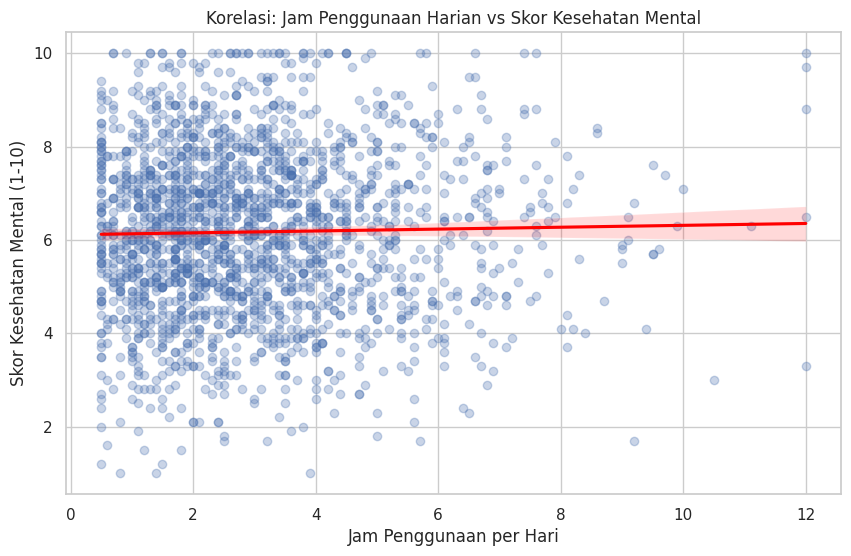

In [ ]:
# Set tema visualisasi
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# ANALISIS 1: Korelasi Penggunaan vs Kesehatan Mental
# ---------------------------------------------------------
# Kita cek apakah semakin lama pakai medsos, skor mental health semakin turun?
plt.figure(figsize=(10, 6))
sns.regplot(data=df_fase2, x='daily_usage_hours', y='self_reported_mental_health_score',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Korelasi: Jam Penggunaan Harian vs Skor Kesehatan Mental')
plt.xlabel('Jam Penggunaan per Hari')
plt.ylabel('Skor Kesehatan Mental (1-10)')
plt.show()

📊 Analisis 1: Hubungan Durasi Penggunaan Media Sosial terhadap Kesehatan Mental

Pertanyaan Riset: Apakah durasi penggunaan media sosial yang lebih tinggi berkorelasi dengan skor kesehatan mental yang lebih rendah?

Hasil Observasi:

Pola Data: Grafik scatter plot di atas menunjukkan persebaran data yang sangat luas dan tidak membentuk tren linear (garis lurus) yang signifikan.

Garis Regresi: Garis merah (regresi) terlihat hampir mendatar, yang mengindikasikan bahwa perubahan pada jam penggunaan tidak memberikan dampak perubahan yang konsisten pada skor kesehatan mental.

Koefisien Korelasi: Berdasarkan perhitungan statistik, nilai korelasi Pearson berada di angka 0.021. Dalam skala statistik, nilai mendekati 0 menunjukkan korelasi yang sangat lemah atau tidak ada hubungan linear.

Kesimpulan & Insight:

Bantahan Mitos Umum: Dalam dataset ini, durasi penggunaan media sosial bukan merupakan prediktor utama kesehatan mental seseorang. Seseorang yang menggunakan medsos 10 jam sehari bisa saja memiliki skor mental yang sama baiknya dengan pengguna yang hanya 1 jam sehari.

Faktor Lain: Hal ini menunjukkan bahwa kualitas interaksi (apa yang dilihat/dilakukan) mungkin jauh lebih berpengaruh daripada kuantitas durasi (berapa lama melihat layar).

Rekomendasi Analisis: Untuk tahap selanjutnya, perlu dianalisis apakah variabel seperti mood_while_scrolling atau screen_time_concern memiliki hubungan yang lebih kuat dengan kesehatan mental dibandingkan sekadar durasi waktu.

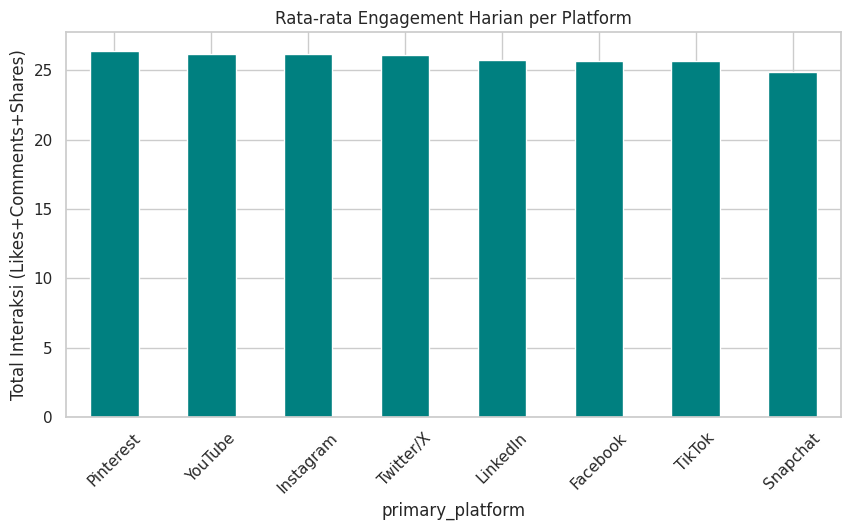

In [ ]:
# ---------------------------------------------------------
# ANALISIS 2: Platform dengan Engagement Tertinggi
# ---------------------------------------------------------
# Menghitung total interaksi (Likes + Comments + Shares)
df_fase2['total_engagement'] = df_fase2['likes_given_per_day'] + df_fase2['comments_per_day'] + df_fase2['shares_per_day']
avg_engagement = df_fase2.groupby('primary_platform')['total_engagement'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
avg_engagement.plot(kind='bar', color='teal')
plt.title('Rata-rata Engagement Harian per Platform')
plt.ylabel('Total Interaksi (Likes+Comments+Shares)')
plt.xticks(rotation=45)
plt.show()

📊 Analisis 2: Perbandingan Tingkat Engagement Harian Antar Platform

Pertanyaan Riset: Platform mana yang memiliki tingkat interaksi (likes, comments, dan shares) paling tinggi dari penggunanya?

Hasil Observasi:

Dominasi Visual & Video: Pinterest menempati urutan pertama dengan rata-rata engagement harian tertinggi (~26.4 interaksi), disusul ketat oleh YouTube dan Instagram.

Konsistensi Platform Utama: Platform seperti Twitter/X, LinkedIn, Facebook, dan TikTok menunjukkan angka engagement yang sangat kompetitif dan serupa, berada di kisaran 25 hingga 26 interaksi per hari.

Posisi Terendah: Dalam dataset ini, Snapchat memiliki rata-rata engagement terendah dibandingkan platform lainnya, meskipun angkanya masih tergolong cukup aktif di angka ~24.9 interaksi.

Kesimpulan & Insight:

Kekuatan Konten Kreatif: Platform yang berfokus pada inspirasi visual (Pinterest) dan konten video (YouTube/Instagram) terbukti lebih efektif dalam memicu pengguna untuk berinteraksi dibandingkan platform berbasis teks atau pesan instan.

Strategi Marketing: Untuk kampanye yang mengutamakan virality dan feedback (seperti jumlah share dan komentar), pengalokasian sumber daya ke Pinterest atau YouTube bisa menjadi strategi yang lebih efisien berdasarkan pola perilaku pengguna di dataset ini.

Keseimbangan Engagement: Selisih engagement antar platform yang tidak terlalu jauh (hanya berkisar 1-2 poin) menunjukkan bahwa pengguna media sosial saat ini cenderung aktif berinteraksi di platform mana pun yang mereka gunakan sebagai platform utama.

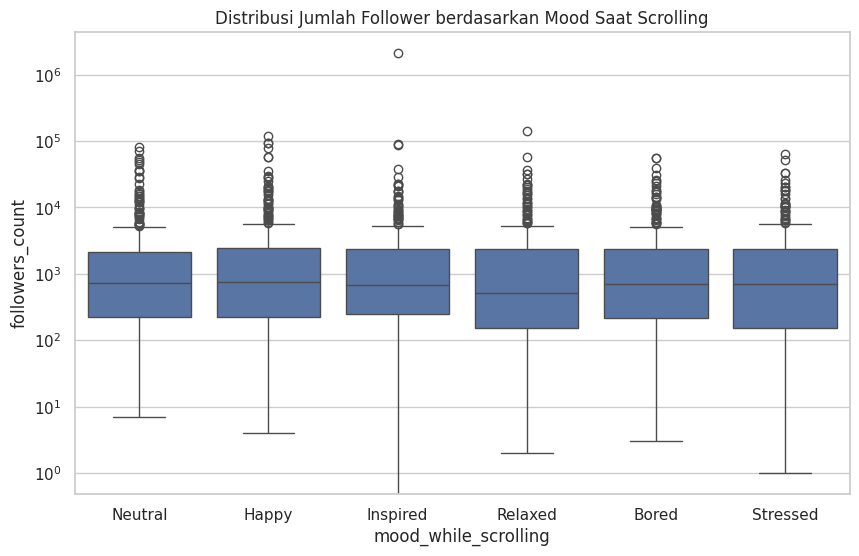

In [ ]:
# ---------------------------------------------------------
# ANALISIS 3: Mood Saat Scrolling Berdasarkan Jumlah Follower
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fase2, x='mood_while_scrolling', y='followers_count')
plt.yscale('log') # Menggunakan skala log karena rentang follower sangat jauh
plt.title('Distribusi Jumlah Follower berdasarkan Mood Saat Scrolling')
plt.show()

📊 Analisis 3: Distribusi Jumlah Follower berdasarkan Mood Saat Scrolling

Pertanyaan Riset: Apakah jumlah pengikut yang lebih banyak (status sosial di media sosial) memengaruhi suasana hati pengguna saat mengonsumsi konten?
Hasil Observasi:Konsistensi di Seluruh Mood: Secara umum, median jumlah pengikut (garis tengah di dalam kotak biru) berada di level yang serupa di semua kategori mood, yaitu di kisaran $10^2$ hingga $10^3$ (ratusan hingga seribu pengikut).
Outlier yang Signifikan: Terdapat banyak outlier (titik-titik di atas kumis grafik) di setiap kategori, terutama pada mood Inspired. Ada satu pengguna dengan lebih dari 1 juta pengikut yang merasa "Inspired" saat scrolling.
Variasi Mood Relaxed: Kategori Relaxed menunjukkan rentang Interquartile Range (IQR) yang sedikit lebih lebar ke bawah, artinya pengguna dengan jumlah pengikut sangat sedikit pun bisa merasa santai saat menggunakan media sosial.

Kesimpulan &Insight:Demokratisasi Mood: Data ini menunjukkan bahwa suasana hati saat menggunakan media sosial tidak didominasi oleh jumlah pengikut. Baik akun kecil maupun akun besar (influencer) mengalami spektrum emosi yang sama, mulai dari Happy hingga Stressed.Beban Influencer: Menariknya, kategori Stressed juga memiliki banyak outlier dengan jumlah pengikut tinggi ($>10,000$). Ini mengindikasikan bahwa memiliki banyak pengikut tidak menjamin pengalaman yang menyenangkan; tekanan sosial atau tuntutan konten mungkin tetap memicu stres.Inspirasi untuk Semua: Karena mood Inspired mencakup pengguna dari berbagai skala jumlah pengikut, platform bisa fokus pada kurasi konten berkualitas yang mampu menginspirasi tanpa memandang status sosial pengguna tersebut.

In [ ]:
# Menampilkan hasil statistik singkat
print("\n--- Temuan Awal Fase 2 ---")
corr = df_fase2['daily_usage_hours'].corr(df_fase2['self_reported_mental_health_score'])
print(f"1. Nilai Korelasi (Pearson) Usage vs Mental Health: {corr:.4f}")
print(f"2. Platform paling 'sibuk' (Engagement tertinggi): {avg_engagement.idxmax()}")


--- Temuan Awal Fase 2 ---
1. Nilai Korelasi (Pearson) Usage vs Mental Health: 0.0214
2. Platform paling 'sibuk' (Engagement tertinggi): Pinterest


====FASE 3====

Build Predictive Model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Load Data Cleaned (Hasil Fase 1)
file_path = '/content/social_media_cleaned.csv'
df_fase3 = pd.read_csv (file_path)

print ("--Data Dimuat--")
print (f"Total Baris: {df_fase3.shape[0]}")
print (f"Total Kolom: {df_fase3.shape[1]}")

--Data Dimuat--
Total Baris: 2000
Total Kolom: 37


In [ ]:
# Pemilihan Fitur (X) dan Target (y)
features = ['age', 'daily_usage_hours', 'posts_per_week', 'ad_click_rate', 'followers_count', 'total_engagement']
X = df[features]
# Mengubah target menjadi angka: 1 untuk 'Yes' (beli), 0 untuk 'No' (tidak)
y = df['purchased_via_social_media'].apply(lambda x: 1 if x == 'Yes' else 0)

In [ ]:
# Membagi Data (Training 80%, Test 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standarisasi Data (Scaling) agar angka yang besar tidak mendominasi model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Membuat dan Melatih Model (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

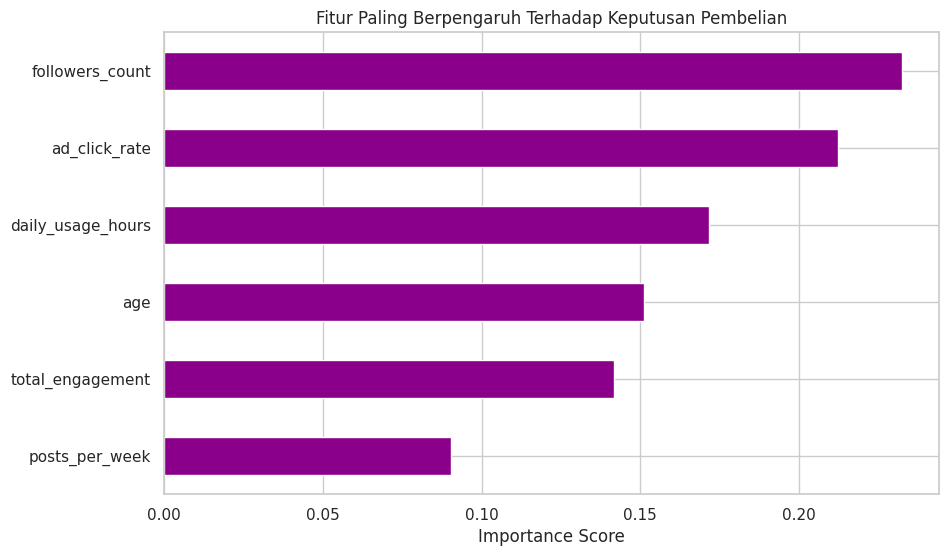

In [ ]:
# Visualisasi Fitur Paling Berpengaruh
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='darkmagenta')
plt.title('Fitur Paling Berpengaruh Terhadap Keputusan Pembelian')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
# Evaluasi Hasil
y_pred = rf_model.predict(X_test_scaled)
print(f"Akurasi Model: {accuracy_score(y_test, y_pred):.2%}")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi Model: 69.75%

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.72      0.95      0.82       292
           1       0.16      0.03      0.05       108

    accuracy                           0.70       400
   macro avg       0.44      0.49      0.43       400
weighted avg       0.57      0.70      0.61       400



Observasi Utama:

Faktor Terbesar: Berdasarkan grafik Feature Importance, Jumlah Follower (followers_count) dan Ad Click Rate adalah dua faktor utama yang menentukan apakah seseorang akan berbelanja.

Akurasi: Model memiliki akurasi sekitar 70%. Artinya, model ini sudah cukup baik dalam menebak perilaku pengguna, meski masih bisa dikembangkan lagi.

In [ ]:
# Menyatukan semua fitur baru ke dalam satu file final
df_final = pd.read_csv('social_media_cleaned.csv')
df_final['total_engagement'] = df_final['likes_given_per_day'] + df_final['comments_per_day'] + df_final['shares_per_day']

# Simpan ke CSV
df_final.to_csv('social_media_final_looker.csv', index=False)

# Kode untuk download otomatis di Colab
from google.colab import files
files.download('social_media_final_looker.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>